In [1]:
import bayesian_optimization as bo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import pathlib

In [2]:
# read result
model_output_dir = pathlib.Path("/Users/jiguangli/BO/models/X03")

result_filename = model_output_dir.joinpath("s01_voltage_experiment_results_30.pkl")
with open(result_filename, 'rb') as input_file:
	results = pickle.load(input_file)

In [3]:
exp_results, opt_info =  results['experiments'], results['opt']

# Voltage Optimization: Section 6.2 of the Manuscript

# Analyaze results

In [5]:
import numpy as np
import pandas as pd

# ----------------------
# Config (edit as needed)
# ----------------------
CHECKPOINTS = [5, 10, 15, 20, 25, 30]     # BO iterations (not counting the 5 init evals)
N_INIT = 5                              # number of initialization evaluations
G_ORDER = ["MES", 0.0, 0.5, 1.0, 1.5, 2.0]  # desired order of g in the output

def build_best_so_far_table(results,
                            checkpoints=CHECKPOINTS,
                            n_init=N_INIT,
                            g_order=G_ORDER):
    """
    Build a flat comparison table:
        columns: g, alpha, iter10, iter20, iter30, iter40, iter50
        rows: for each g in g_order (when present), alpha=1 then alpha=hw,
              each value is the mean across seeds/runs.
    """
    def _normalize_alpha(a):
        s = str(a).strip().lower()
        if s in {"1", "1.0", "1.00", "1.000"}:
            return "1"
        if s in {"hw", "tempered"}:
            return "hw"
        return s

    def _normalize_g(g):
        s = str(g).strip()
        if s.upper() == "MES":
            return "MES"
        try:
            return float(s)
        except Exception:
            return s

    def _extract_checkpoint_values(best_arr, checkpoints, n_init):
        best_arr = np.asarray(best_arr)
        out = {}
        for t in checkpoints:
            idx = n_init + t - 1  # 0-based position in best_so_far
            if idx >= len(best_arr):
                raise ValueError(
                    f"'best_so_far' length {len(best_arr)} too short for iteration {t} with n_init={n_init}."
                )
            out[f"iter{t}"] = float(best_arr[idx])
        return out

    def _g_sort_key(val):
        # order by g_order; unknowns go to bottom
        try:
            if val == "MES":
                return g_order.index("MES")
            if isinstance(val, (int, float)):
                return g_order.index(float(val)) if float(val) in g_order else 999
            f = float(val)
            return g_order.index(f) if f in g_order else 999
        except Exception:
            return 999

    # 1) Flatten each run into one row: (g, alpha, iter10..iter50)
    rows = []
    for r in results:
        best = r.get("best_so_far")
        if best is None:
            continue
        g = _normalize_g(r.get("g"))
        alpha = _normalize_alpha(r.get("alpha"))
        vals = _extract_checkpoint_values(best, checkpoints, n_init)
        rows.append({"g": g, "alpha": alpha, **vals})

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No usable results found. Ensure each dict has 'best_so_far' plus 'g' and 'alpha'.")

    # 2) Aggregate: mean across runs for each (g, alpha)
    iter_cols = [f"iter{t}" for t in checkpoints]
    mean_df = df.groupby(["g", "alpha"], as_index=False)[iter_cols].mean(numeric_only=True)

    # 3) Sort: by g (custom order) then by alpha (1, hw)
    alpha_order = {"1": 0, "hw": 1}
    mean_df["g_sort"] = mean_df["g"].apply(_g_sort_key)
    mean_df["alpha_sort"] = mean_df["alpha"].map(alpha_order).fillna(99)
    mean_df = mean_df.sort_values(["g_sort", "alpha_sort"]).drop(columns=["g_sort", "alpha_sort"])

    # 4) Final column order
    out = mean_df[["g", "alpha"] + iter_cols].reset_index(drop=True)
    return out

table = build_best_so_far_table(exp_results)

## Recreating Table 3

In [6]:
table

,g,alpha,iter5,iter10,iter15,iter20,iter25,iter30
0,MES,1,5.244187,5.542870,5.687650,5.906776,6.292336,6.537704
1,MES,hw,5.047614,5.158649,5.551071,6.017854,6.017854,6.105913
2,0.0,1,5.072557,5.216988,5.335539,5.335539,5.389902,5.394254
3,0.0,hw,4.985941,5.509554,5.985530,5.990089,6.256510,6.256510
4,0.5,1,5.435038,6.089558,6.138694,6.646735,6.833154,6.834120
5,0.5,hw,5.434079,5.984924,6.998355,7.017270,7.018159,7.047042
6,1.0,1,5.290367,5.439139,5.711982,5.793758,6.005960,6.208248
7,1.0,hw,5.197762,5.202578,5.852262,6.858881,7.192716,7.264755
8,1.5,1,5.134462,5.399661,5.568679,5.683474,5.683833,5.806065
9,1.5,hw,5.134462,5.399661,5.938927,6.053723,6.053723,6.053723


## Visualization -- Recreating Figure 4

In [ ]:
from collections import defaultdict

# # -------------------
# # Config
# # -------------------
N_INIT = 5                 # number of initialization evaluations
N_TOTAL = 35               # total evaluations (5 init + 30 iterations)
ALPHA_ORDER = ["1", "hw"]  # plotting order
G_ORDER = ["MES", 0.0, 0.5, 1.0, 1.5, 2.0]  # panel order (3x2)

# Colors / labels
ALPHA_LABELS = {"1": "1", "hw": "Tempered"}
ALPHA_COLORS = {"1": "#3B6FB6", "hw": "#D16E4B"}  

def _normalize_alpha(a):
    s = str(a).strip().lower()
    if s in {"1", "1.0", "1.00", "1.000"}:
        return "1"
    if s in {"hw", "tempered"}:
        return "hw"
    return s

def _normalize_g(g):
    s = str(g).strip()
    if s.upper() == "MES":
        return "MES"
    try:
        return float(s)
    except Exception:
        return s

def _stack_runs(results, key="best_so_far"):
    """
    Returns: data[g][alpha] -> np.ndarray of shape (n_seeds, N_TOTAL)
    """
    buckets = defaultdict(lambda: defaultdict(list))
    for r in results:
        if key not in r:
            continue
        arr = np.asarray(r[key])
        # Only keep runs with expected length
        if arr.ndim != 1 or len(arr) != N_TOTAL:
            continue

        g = _normalize_g(r.get("g"))
        alpha = _normalize_alpha(r.get("alpha"))
        buckets[g][alpha].append(arr)

    # convert lists to arrays
    out = {}
    for g, d in buckets.items():
        out[g] = {}
        for a, lst in d.items():
            if len(lst) == 0:
                continue
            out[g][a] = np.vstack(lst)  # (n_runs, N_TOTAL)
    return out


In [ ]:
def plot_best_so_far_panels(results):
    data = _stack_runs(results, key="best_so_far")

    # 3x2 layout
    fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True, sharey=True)
    axes = axes.ravel()

    x = np.arange(1, N_TOTAL + 1)

    for idx, (ax, g) in enumerate(zip(axes, G_ORDER)):
        ax.set_title(f"g = {g}")
        ax.axvline(N_INIT, linestyle="--", linewidth=1, alpha=0.35)

        for a in ALPHA_ORDER:
            runs = data.get(g, {}).get(a)
            if runs is None:
                continue

            mean = runs.mean(axis=0)
            q25  = np.percentile(runs, 25, axis=0)
            q75  = np.percentile(runs, 75, axis=0)

            color = ALPHA_COLORS.get(a)
            label = ALPHA_LABELS.get(a, a)

            # main line + band
            line, = ax.plot(x, mean, lw=2, label=label, color=color)
            ax.fill_between(x, q25, q75, alpha=0.15, color=color)

            ax.scatter(
                np.full(runs.shape[0], x[-1]),  # all at last x
                runs[:, -1],                    # final best-so-far per seed
                s=10, alpha=0.6,
                color=color,
                zorder=3,
            )


            ax.annotate(
                f"{mean[-1]:.3g}",
                (x[-1], mean[-1]),
                xytext=(4, 0),
                textcoords="offset points",
                fontsize=8,
                va="center",
            )


        if idx >= 4:
            ax.set_xlabel("Evaluations")
        ax.grid(True, which="both", alpha=0.2)


    for i in range(len(G_ORDER), len(axes)):
        axes[i].axis("off")

    fig.supylabel("Best observed value (mean across seeds)", x=0.02)
    fig.suptitle("Bayesian Optimization: Growth of Best-So-Far (5 init + 30 iters)", y=0.9)

    fig.subplots_adjust(left=0.08, right=0.98, top=0.83, bottom=0.08,
                        hspace=0.28, wspace=0.18)

    # One legend for all panels at the top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper left", ncol=2,
               frameon=False, bbox_to_anchor=(0.5, 0.945))

    fig.savefig("voltage_best_so_far.pdf", bbox_inches="tight", dpi=300)
    plt.show()


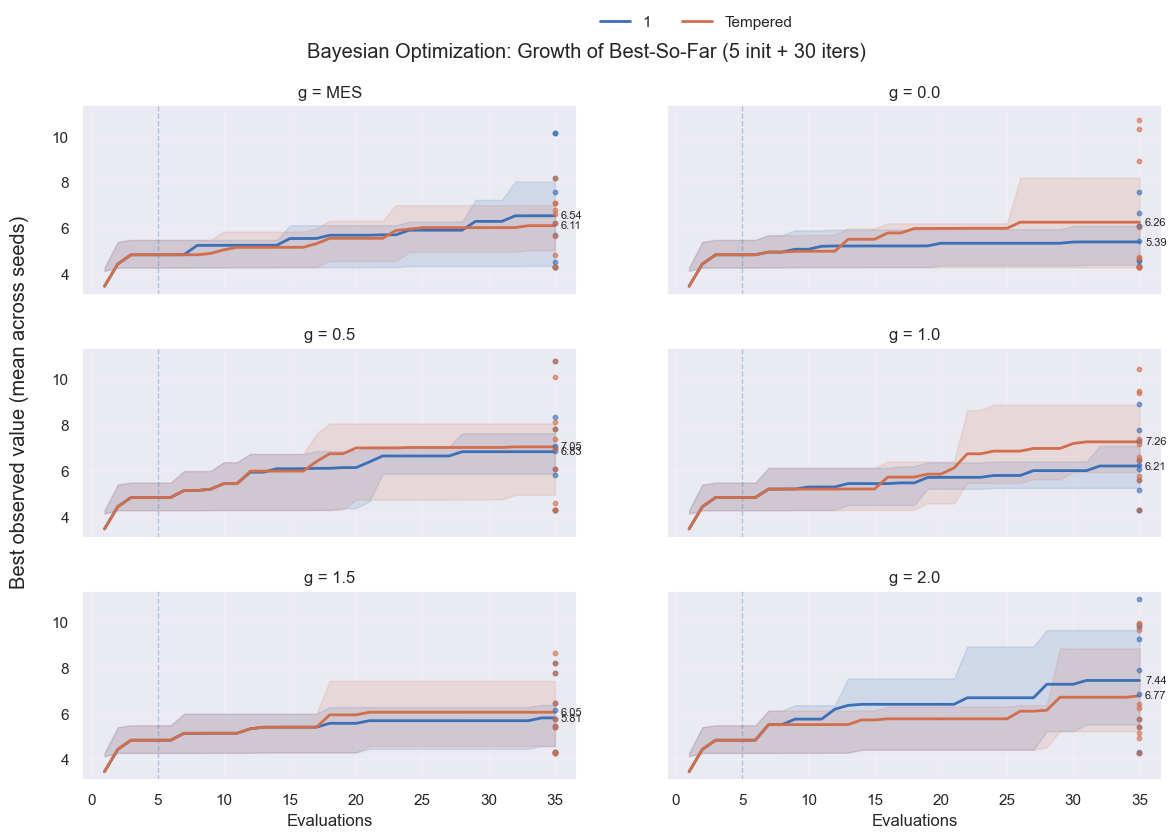

In [9]:
plot_best_so_far_panels(exp_results)